# Exercise #1. PCA 

This first example allows you to go through PCA step by step.
It is applied on the data of student marks presented during the course.

---

Rappel des étapes de l'ACP :

- Centrer et réduire les données X
- Calculer la matrice de covariance des données : X.T * X
- Calculer les valeurs et vecteurs propres de la matrice de covariance.
- Ordonner les couples (valeur propre : a_i, vecteur propres : v_i) par ordre décroissant des valeurs propres.
- Garder les q premiers couples afin de construire la matrice V = [v1 v2 … vq].
- Ici : la valeur propres a_i est égale à l'inertie portée par l'axe v_i.


Import needed packages

In [6]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import normalize 
import matplotlib as mpl
import matplotlib.pyplot as plt

Laoding the data

In [7]:
df = pd.read_csv("marks.csv")
X = df.iloc[:, 1:].values     # The Original matrix. Each row is an 4 dim figures.
names = df.iloc[:, :1].values # The name of the student.

In [8]:
print(names)

print(np.std(X, axis=0, ddof=0))
print(np.mean(X, axis=0))

[['jean']
 ['alan']
 ['anni']
 ['moni']
 ['didi']
 ['andr']
 ['pier']
 ['brig']
 ['evel']]
[3.37474279 2.99072641 3.47299991 2.81310864]
[ 9.66666667  9.83333333 10.22222222 10.05555556]


## Standardisation of X
Standardization refers to shifting the distribution of each attribute to have a mean of zero and a standard deviation of one (unit variance). It is useful to standardize attributes for a model. Standardization of datasets is a common requirement for many machine learning estimators implemented in scikit-learn; they might behave badly if the individual features do not more or less look like standard normally distributed data

In [9]:
# COMPLETE THE CODE HERE
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

Xn = (X - mean) / std
print(Xn)

[[-1.08650256 -1.28173989 -1.50366322 -1.61940264]
 [-0.4938648  -0.61300603 -0.63985669 -0.73070607]
 [-1.08650256 -0.94737296  0.22394984 -0.19748813]
 [ 1.43220792  1.560379    1.51965963  1.75764432]
 [ 1.28404848  1.39319553  0.51188535  0.86894776]
 [ 0.39509184  0.05572782 -1.35969546 -1.0861847 ]
 [-1.234662   -0.94737296  1.08775637  0.51346913]
 [ 0.9877296   0.89164514 -0.49588893 -0.19748813]
 [-0.19754592 -0.11145564  0.65585311  0.69120844]]


Compute and print the mean and the standard deviation of the transformed data (Xn) using "np.mean" and "np.std". What do you notice?

In [10]:
# COMPLETE THE CODE HERE
print(np.std(Xn, axis=0, ddof=0))
print(np.round(np.mean(Xn, axis=0), 2))

[1. 1. 1. 1.]
[ 0. -0.  0.  0.]


## Computing the covariance matrix

In [11]:
# COMPLETE THE CODE HERE
cov_mat = np.cov(Xn.T , ddof=0)
print('Covariance matrix shape: ',cov_mat.shape)
print('Covariance matrix \n%s' %cov_mat)


Covariance matrix shape:  (4, 4)
Covariance matrix 
[[1.         0.98253573 0.22673193 0.50814398]
 [0.98253573 1.         0.39669324 0.65153051]
 [0.22673193 0.39669324 1.         0.95120575]
 [0.50814398 0.65153051 0.95120575 1.        ]]


## Eigen decomposition of the covariance matrix

Here, the function "eig" from the linear algebra package of Numpy can be used ("np.linalg")


In [12]:
# COMPLETE THE CODE HERE
eig_vals, eig_vecs = np.linalg.eig(cov_mat)

print('Eigenvectors shape: ', eig_vecs.shape)
print('Eigenvalues shape: ', eig_vals.shape)

Eigenvectors shape:  (4, 4)
Eigenvalues shape:  (4,)


In [21]:
eig_vecs

array([[-0.47845402, -0.55194891,  0.65222562,  0.20257316],
       [-0.53191716, -0.40680183, -0.59742507, -0.44120255],
       [-0.44393038,  0.62123362,  0.36542644, -0.53240785],
       [-0.53951061,  0.37938563, -0.29008368,  0.69343082]])

## Selecting Principal Components

In [13]:
# Make a list of (eigenvalue, eigenvector) tuples
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:,i]) for i in range(len(eig_vals))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Visually confirm that the list is correctly sorted by decreasing eigenvalues
print('Eigenvalues in descending order (All the eigenvalues):')
for tup in eig_pairs[:len(eig_vals)]:
    print(tup[0])

Eigenvalues in descending order (All the eigenvalues):
2.8756867715196894
1.1196873635606144
0.0035775900861775996
0.0010482748335192429


### What do you notice? Analyze the obtained eigen values.
The last two eigenvalues are very small compared with the first two. Therefore, the first two principal components contain most of the variance, while the last two contribute little information. We can reduce the dimensionality by keeping only the first two eigenvectors with minimal information loss.

### Explain the relationship between the eigen values and the covariance matrix
The covariance matrix suggests a strong correlation between Math and Physics, and another one between English and French. This matches the presence of two high eigenvalues

## Explained Variance 
After sorting the eigenpairs, the next question is "how many principal components are we going to choose for our new feature subspace?" A useful measure is the so-called "explained variance," which can be calculated from the eigenvalues. The explained variance tells us how much information (variance) can be attributed to each of the principal components.

In [14]:

tot_ev = sum(eig_vals)
var_exp = [(cur_ev / tot_ev)*100 for cur_ev in sorted(eig_vals, reverse=True)]

print(var_exp[:10])

[np.float64(71.89216928799223), np.float64(27.992184089015353), np.float64(0.08943975215443997), np.float64(0.026206870837981067)]


#### Plotting the eigen values considering the explained variance ratio (%).

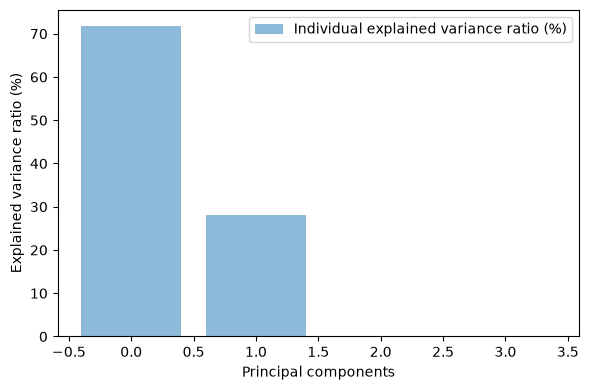

In [15]:
num_eig_val = 4

plt.figure(figsize=(6, 4))
plt.bar(range(num_eig_val), var_exp[:num_eig_val], alpha=0.5, label='Individual explained variance ratio (%)')
plt.ylabel('Explained variance ratio (%)')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.tight_layout()

## Projection matrix

The construction of the projection matrix that will be used to transform the initial data onto the new feature subspace. 

In the present case, only 1st and 2nd principal component shares the most inmportant part of information.

Hence, we can drop other components. Here, we are reducing the 4-dimensional feature space to a 2-dimensional feature subspace, by choosing the “top 2” eigenvectors with the highest eigenvalues to construct our d×k-dimensional eigenvector matrix W

In [17]:
W = np.hstack((eig_pairs[0][1].reshape(4,1), 
               eig_pairs[1][1].reshape(4,1)
            ))
print('Matrix W shape :\n', W.shape)

Matrix W shape :
 (4, 2)


### Projection into the New Feature Space (of reduced dimension)


In [18]:
# COMPLETE THE CODE HERE

Xproj = Xn.dot(W)
print(Xproj.shape)

(9, 2)


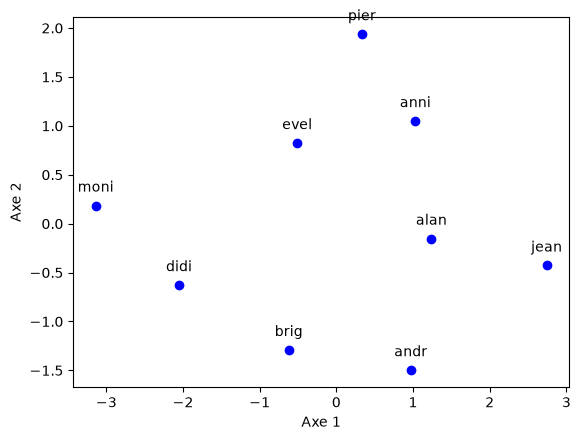

In [19]:
plt.plot(Xproj[:,0], Xproj[:,1], 'bo')
plt.ylabel('Axe 2')
plt.xlabel('Axe 1')

i=0;
for x,y in zip(Xproj[:,0],Xproj[:,1]):
        plt.annotate(names[i,0], (x,y), textcoords="offset points",
                 xytext=(0,10), # distance from text to points (x,y)
                 ha='center') # horizontal alignment can be left, right or center
        i = i+1
plt.show()

# Your analysis here...

The projection graph can be interpreted by examining the two principal-component vectors:

1. The first principal-component vector has negative coefficients with approximately similar magnitudes for all four subjects. Therefore, it represents a combination of all the marks, but in the opposite direction. Consequently, moving to the left along the first axis generally corresponds to students with higher average marks.

2. The second principal-component vector assigns negative weights to Mathematics and Physics and positive weights to French and English. Thus, students with relatively higher Mathematics and Physics marks tend to have lower coordinates on the second axis, whereas students with relatively higher French and English marks tend to have higher coordinates. Students with a more balanced performance across these subject groups are located near the middle of the second axis.


# Otherwise, we can use "scikit-learn"

Every thing can be done in 2 lignes!

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Xproj2 = pca.fit_transform(Xn)

print(Xproj2.shape)

(9, 2)


### And we can check that resulting PCAs are equivalent.

In [29]:
print('Xproj:', Xproj[5:,])
print('Xproj2:', Xproj2[5:,])

print (eig_vecs[:, :2].T)
print ('sickit_vecs' ,pca.components_)


print(pca.explained_variance_)

ev = [cur_ev for cur_ev in sorted(eig_vals, reverse=True)]
print(ev[:4])

Xproj: [[ 0.97094243 -1.49751209]
 [ 0.33474278  1.93741704]
 [-0.62017744 -1.29088619]
 [-0.5102656   0.82404816]]
Xproj2: [[-0.97094243 -1.49751209]
 [-0.33474278  1.93741704]
 [ 0.62017744 -1.29088619]
 [ 0.5102656   0.82404816]]
[[-0.47845402 -0.53191716 -0.44393038 -0.53951061]
 [-0.55194891 -0.40680183  0.62123362  0.37938563]]
sickit_vecs [[ 0.47845402  0.53191716  0.44393038  0.53951061]
 [-0.55194891 -0.40680183  0.62123362  0.37938563]]
[3.23514762 1.25964828]
[np.float64(2.8756867715196894), np.float64(1.1196873635606144), np.float64(0.0035775900861775996), np.float64(0.0010482748335192429)]


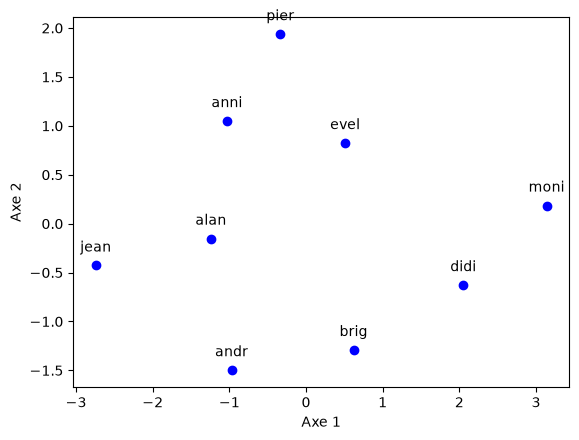

In [23]:
plt.plot(Xproj2[:,0], Xproj2[:,1], 'bo')
plt.ylabel('Axe 2')
plt.xlabel('Axe 1')

i=0;
for x,y in zip(Xproj2[:,0],Xproj2[:,1]):
        plt.annotate(names[i,0], (x,y), textcoords="offset points",
                 xytext=(0,10), # distance from text to points (x,y)
                 ha='center') # horizontal alignment can be left, right or center
        i = i+1
plt.show()

# Is there any difference between the two methods (step-by-step and using "scikit-learn") ?

# Explain...
Both methods produce equivalent PCA results. The only visible difference is that the first axis is reversed. This is because the sign of an eigenvector is arbitrary: an eigenvector and its negative represent the same direction. Consequently, the two graphs may be mirror images of each other without indicating any difference in the PCA results.